# Task 1 — Fashion Item Type Classification

**COSC2753 Assignment 2** · Neural network approach

Given a fashion-item image, predict **what type of item it is** (`articleType`) — T-shirt,
Shirt, Jeans, Shoes, Bags, Watches, and roughly 120 other fine-grained categories.

## Problem framing

Unlike Task 2 (season, ~4 classes) or Task 3 (gender/usage, 5/4 classes), `articleType` has
**124 raw classes** with severe long-tail imbalance: the largest class (`Tshirts`) has 6,781
examples while 7 classes have exactly 1. A model, and a train/val/test split, cannot be built
on 124 classes as-is — `StratifiedGroupKFold` requires enough independent product groups per
class to place at least one in each of train, validation and test.

**Rare-class strategy.** Classes with fewer than `min_class_size=10` training examples are
dropped rather than merged into a catch-all `"Other"` class. Task 3 already measured what a
catch-all class costs: pooling four rare `usage` values into `"Other"` produced a class with
F1 = 0.000, because a group of otherwise-unrelated items shares no visual signature. Here the
32 rare classes are wildly heterogeneous (`Ipad`, `Umbrellas`, `Shoe Laces`, `Rain Jacket`, ...)
— there is no defensible merge target for them, so `"Other"` would be even less coherent than
Task 3's version. Dropping removes 121 of 38,612 rows (0.31%) and leaves **92 classes**, all
with enough support to stratify.

This has one unavoidable consequence for the unseen test set: an item whose true class is one
of the 32 dropped ones can never be predicted correctly, because that class has no output
logit. Section 17 quantifies this explicitly as the required "how does data quality affect
results" analysis.

## Algorithms investigated

Four models are compared, spanning **three different algorithm families** (the assignment
requires "different types of algorithms", not just different neural architectures):

1. **Majority-class baseline** — the floor every model must beat.
2. **Classical ML** — hand-crafted colour (HSV histogram) and texture (gradient-grid) features
   fed into a `LogisticRegression`. No gradient descent over pixels, no learned convolutional
   features — a genuinely different algorithm family from the two neural nets below.
3. **MLP on flattened pixels** — a deliberately weaker neural baseline that discards spatial
   structure, run for the same reason Task 3 ran one: to demonstrate *why* convolution is the
   right inductive bias here, rather than asserting it.
4. **CNN (submitted model)** — a convolutional network trained from scratch (pretrained weights
   are forbidden by the assignment specification).

## Evaluation strategy

* **Grouped, stratified hold-out** (train / validation / test), grouped by `productDisplayName`
  to stop near-duplicate catalogue photos leaking across partitions — identical to Task 2/3.
* **Weighted-F1 and top-3 accuracy as the two headline metrics**, not macro-F1. With 92 classes
  many still holding only 10-30 examples, macro-F1 is dominated by noise from classes with a
  handful of test rows — a single misclassification can swing a class's F1 from 1.0 to 0.0.
  Weighted-F1 and top-3 accuracy reflect real-world performance across the actual population.
  Macro-F1 / balanced accuracy are still reported as the long-tail diagnostic.
* **3-seed repeat instead of k-fold CV.** With the rarest surviving class holding only 10
  examples, a 3-fold split would leave ~3 examples/class/fold — not meaningful. Repeating the
  final configuration with 3 different random seeds (same split) gives a noise-floor estimate
  without that problem.

## Compute budget note

This machine has no CUDA/MPS accelerator (CPU-only, 14 threads). The architecture width,
epoch budget and search budget below are deliberately smaller than Task 3's (which had a GPU)
so the full notebook completes in a practical amount of time. This is stated explicitly rather
than silently — see `CONFIG` below.

## 1. Setup, configuration and reproducibility

In [1]:
# ============================================
# CELL 1 - Imports, device and global configuration
# ============================================

import os
import json
import time
import copy
import random
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

from PIL import Image

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 60)

RANDOM_STATE = 42


def set_seed(seed=RANDOM_STATE):
    """Seed every source of randomness we rely on."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if torch.backends.mps.is_available():
        torch.mps.manual_seed(seed)


set_seed()

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("PyTorch:", torch.__version__)
print("Device :", DEVICE)
if DEVICE.type == "cuda":
    print("GPU    :", torch.cuda.get_device_name(0))
    torch.backends.cudnn.benchmark = True
else:
    print("CPU threads:", torch.get_num_threads())

PyTorch: 2.11.0+cu128
Device : cpu
CPU threads: 14


In [2]:
# ============================================
# CELL 2 - Paths (mirrors 01_eda.ipynb / 04_task3_gender_usage.ipynb)
# ============================================

NOTEBOOK_DIR = Path.cwd()
PROJECT_DIR = NOTEBOOK_DIR.parent

DATASET_ROOT = PROJECT_DIR / "A2_FashionDataset"
DATASET_DIR = DATASET_ROOT / "FashionDataset"

TRAIN_DIR = DATASET_DIR / "train"
TEST_DIR = DATASET_DIR / "test"

TRAIN_IMAGE_DIR = TRAIN_DIR / "images_train"
TEST_IMAGE_DIR = TEST_DIR / "images_test"

PROCESSED_DIR = DATASET_ROOT / "processed"
ARTIFACT_DIR = PROJECT_DIR / "artifacts" / "task1"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

OUTPUT_DIR = PROJECT_DIR / "outputs"
OUTPUT_EVAL_DIR = OUTPUT_DIR / "evaluation"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_EVAL_DIR.mkdir(parents=True, exist_ok=True)

CLEAN_METADATA = PROCESSED_DIR / "clean_train_metadata.csv"
PREDICTION_METADATA = PROCESSED_DIR / "prediction_metadata.csv"

assert CLEAN_METADATA.exists(), (
    f"Cannot find {CLEAN_METADATA}. Run 01_eda.ipynb first - it produces this file."
)

print("Processed directory:", PROCESSED_DIR)
print("Artifact directory :", ARTIFACT_DIR)

Processed directory: D:\machine learning\a2\Fashion-Intelligence-System\A2_FashionDataset\processed
Artifact directory : D:\machine learning\a2\Fashion-Intelligence-System\artifacts\task1


In [3]:
# ============================================
# CELL 3 - Experiment configuration
# ============================================

# This CPU-only machine has no CUDA/MPS accelerator. A quick benchmark of the
# full-width architecture (widths=(32,64,128,256), batch=128) measured ~2.4s
# per training batch, i.e. roughly 8 minutes per epoch on the ~27k-row training
# split - far too slow for a hyperparameter search plus a 3-seed robustness
# check. Every budget knob below is sized for CPU-only training; widen/lengthen
# them first if this notebook is ever re-run on a GPU machine.

CONFIG = {
    # --- image ---
    "image_width": 60,
    "image_height": 80,
    "channels": 3,

    # --- target ---
    "target": "articleType",
    "min_class_size": 10,   # classes below this are dropped - see markdown above

    # --- splitting ---
    "test_fraction": 0.15,
    "val_fraction": 0.15,
    "group_column": "productDisplayName",

    # --- training (CPU-budgeted, see note above) ---
    "batch_size": 128,
    "max_epochs": 15,
    "learning_rate": 1e-3,
    "weight_decay": 1e-4,
    "early_stopping_patience": 4,
    "ablation_patience": 4,
    "lr_patience": 2,
    "grad_clip": 5.0,
    "use_amp": True,
    "use_class_weights": True,
    "label_smoothing": 0.05,

    # --- augmentation ---
    # "gentle" = horizontal flip only, matches Task 3's finding that these are
    # centred catalogue photos where heavy affine/colour augmentation hurts.
    "augmentation": "gentle",

    # --- dataloader ---
    # Keep at 0 on Windows: Jupyter uses 'spawn' and worker processes cannot
    # pickle classes defined inside a notebook, which hangs the kernel.
    "num_workers": 0,

    # --- CNN architecture starting point (CPU-budgeted: narrower than Task 3) ---
    "widths": (16, 32, 64, 128),
    "head_hidden": 128,
    "dropout": 0.4,

    # --- search / robustness budget (lower = faster; raise for a GPU re-run) ---
    "ablation_max_epochs": 6,
    "search_budget": 2,
    "seed_repeats": 3,
}

IMAGE_SIZE_PIL = (CONFIG["image_width"], CONFIG["image_height"])
IMAGE_SHAPE = (CONFIG["image_height"], CONFIG["image_width"], 3)

print(json.dumps({k: (list(v) if isinstance(v, tuple) else v) for k, v in CONFIG.items()},
                  indent=2))

{
  "image_width": 60,
  "image_height": 80,
  "channels": 3,
  "target": "articleType",
  "min_class_size": 10,
  "test_fraction": 0.15,
  "val_fraction": 0.15,
  "group_column": "productDisplayName",
  "batch_size": 128,
  "max_epochs": 15,
  "learning_rate": 0.001,
  "weight_decay": 0.0001,
  "early_stopping_patience": 4,
  "ablation_patience": 4,
  "lr_patience": 2,
  "grad_clip": 5.0,
  "use_amp": true,
  "use_class_weights": true,
  "label_smoothing": 0.05,
  "augmentation": "gentle",
  "num_workers": 0,
  "widths": [
    16,
    32,
    64,
    128
  ],
  "head_hidden": 128,
  "dropout": 0.4,
  "ablation_max_epochs": 6,
  "search_budget": 2,
  "seed_repeats": 3
}


## 2. Load metadata and rebuild local image paths

The notebook consumes `clean_train_metadata.csv` produced by `01_eda.ipynb`, which has already
had the CSV parsing artefacts repaired and rows without images removed. The `image_path` column
inside that CSV holds absolute paths baked in on another machine, so it is rebuilt locally from
`id` here, exactly like Task 2/3.

In [4]:
# ============================================
# CELL 4 - Load metadata and rebuild local image paths
# ============================================

data = pd.read_csv(CLEAN_METADATA)
data["image_path"] = data["id"].apply(lambda i: TRAIN_IMAGE_DIR / f"{i}.jpg")
assert data["image_path"].apply(lambda p: p.exists()).all(), "Some training images are missing"
assert len(data) == 38612, f"Expected 38612 rows, found {len(data)}"

print("Rows:", len(data), "| Columns:", list(data.columns))

prediction_df_raw = pd.read_csv(PREDICTION_METADATA)
prediction_df_raw["image_path"] = prediction_df_raw["id"].apply(lambda i: TEST_IMAGE_DIR / f"{i}.jpg")
assert prediction_df_raw["image_path"].apply(lambda p: p.exists()).all(), "Some unseen images are missing"
assert len(prediction_df_raw) == 5829, f"Expected 5829 unseen rows, found {len(prediction_df_raw)}"

print("Unseen prediction rows:", len(prediction_df_raw))

Rows: 38612 | Columns: ['id', 'gender', 'masterCategory', 'subCategory', 'articleType', 'baseColour', 'season', 'year', 'usage', 'productDisplayName', 'image_path']


Unseen prediction rows: 5829


## 3. Target exploration

articleType: 124 classes, 0 missing, 38612 rows

Top 15 classes:


,Count
articleType,
Tshirts,6780
Shirts,3087
Casual Shoes,2683
Watches,2252
Sports Shoes,1991
Tops,1614
Kurtas,1556
Handbags,1439
Heels,1048



Bottom 15 classes:


,Count
articleType,
Trolley Bag,3
Lehenga Choli,2
Key chain,2
Robe,2
Shapewear,2
Concealer,2
Baby Dolls,2
Rain Jacket,2
Rain Trousers,2


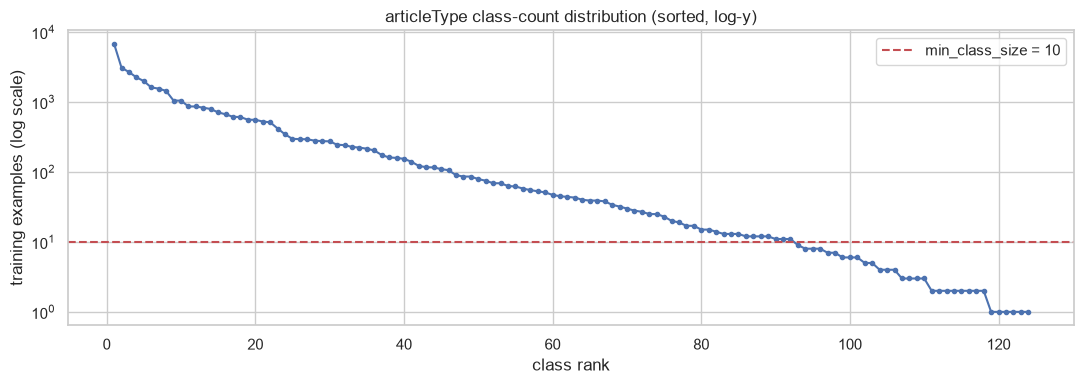


32 of 124 classes have fewer than 10 examples.


In [5]:
# ============================================
# CELL 5 - articleType distribution
# ============================================

target = CONFIG["target"]
assert data[target].isna().sum() == 0, "Unexpected missing articleType labels"

counts = data[target].value_counts()
print(f"{target}: {data[target].nunique()} classes, 0 missing, {len(data)} rows")
print("\nTop 15 classes:")
display(counts.head(15).to_frame("Count"))
print("\nBottom 15 classes:")
display(counts.tail(15).to_frame("Count"))

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(range(1, len(counts) + 1), counts.values, marker="o", markersize=3)
ax.set_yscale("log")
ax.axhline(CONFIG["min_class_size"], color="r", ls="--",
           label=f"min_class_size = {CONFIG['min_class_size']}")
ax.set_xlabel("class rank")
ax.set_ylabel("training examples (log scale)")
ax.set_title("articleType class-count distribution (sorted, log-y)")
ax.legend()
plt.tight_layout()
plt.show()

n_rare = int((counts < CONFIG["min_class_size"]).sum())
print(f"\n{n_rare} of {len(counts)} classes have fewer than "
      f"{CONFIG['min_class_size']} examples.")

## 4. Rare-class handling

Classes with fewer than `min_class_size` training examples are dropped (see markdown at the
top of the notebook for why "merge into Other" is rejected here). Dropped classes and their
counts are saved to `dropped_classes.json` so the data-quality section (Section 17) and the
report can reference exactly which items are affected.

In [6]:
# ============================================
# CELL 6 - Drop rare articleType classes
# ============================================

n_start = len(data)
rare_classes = counts[counts < CONFIG["min_class_size"]].index.tolist()

dropped_info = []
for cls in rare_classes:
    rows = data[data[target] == cls]
    dropped_info.append({
        "articleType": cls,
        "count": int(len(rows)),
        "masterCategory": rows["masterCategory"].mode().iat[0] if len(rows) else None,
        "subCategory": rows["subCategory"].mode().iat[0] if len(rows) else None,
    })

model_df = data[~data[target].isin(rare_classes)].copy()

with open(ARTIFACT_DIR / "dropped_classes.json", "w") as f:
    json.dump(dropped_info, f, indent=2)

print(f"Dropped {len(rare_classes)} classes / {n_start - len(model_df)} rows "
      f"({(n_start - len(model_df)) / n_start * 100:.2f}%)")
print(f"Retained {model_df[target].nunique()} classes / {len(model_df)} rows")
print("Saved", ARTIFACT_DIR / "dropped_classes.json")

model_df["split_group"] = model_df[CONFIG["group_column"]].fillna(
    "__ID_" + model_df["id"].astype(str)
)

Dropped 32 classes / 121 rows (0.31%)
Retained 92 classes / 38491 rows
Saved D:\machine learning\a2\Fashion-Intelligence-System\artifacts\task1\dropped_classes.json


## 5. Label encoding

In [7]:
# ============================================
# CELL 7 - Encode articleType
# ============================================

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
model_df["label"] = encoder.fit_transform(model_df[target].astype(str))
class_names = list(encoder.classes_)
NUM_CLASSES = len(class_names)

print(f"{target}: {NUM_CLASSES} classes")

# Persist immediately - predictions cannot be decoded without this
with open(ARTIFACT_DIR / "label_classes.json", "w") as f:
    json.dump(class_names, f, indent=2)
print("Saved", ARTIFACT_DIR / "label_classes.json")

articleType: 92 classes
Saved D:\machine learning\a2\Fashion-Intelligence-System\artifacts\task1\label_classes.json


## 6. Baselines

Before any model is trained, the numbers it must beat are established. Reporting accuracy
alone would be misleading with 92 imbalanced classes, so macro-F1, weighted-F1 and balanced
accuracy are all reported for the baselines too.

In [8]:
# ============================================
# CELL 8 - Majority-class and stratified-random baselines
# ============================================

from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, f1_score, balanced_accuracy_score,
                              classification_report, confusion_matrix)

baseline_rows = []
X_dummy = np.zeros((len(model_df), 1))
y_all = model_df["label"].values

for strategy in ["most_frequent", "stratified"]:
    dummy = DummyClassifier(strategy=strategy, random_state=RANDOM_STATE)
    dummy.fit(X_dummy, y_all)
    pred = dummy.predict(X_dummy)
    baseline_rows.append({
        "Baseline": strategy,
        "Accuracy": round(accuracy_score(y_all, pred) * 100, 2),
        "MacroF1": round(f1_score(y_all, pred, average="macro", zero_division=0) * 100, 2),
        "WeightedF1": round(f1_score(y_all, pred, average="weighted", zero_division=0) * 100, 2),
        "BalancedAcc": round(balanced_accuracy_score(y_all, pred) * 100, 2),
    })

baseline_df = pd.DataFrame(baseline_rows)
display(baseline_df)

BASELINE = baseline_df[baseline_df["Baseline"] == "most_frequent"].iloc[0].to_dict()
print(f"Target to beat (majority class): accuracy {BASELINE['Accuracy']:.2f}%  "
      f"weighted-F1 {BASELINE['WeightedF1']:.2f}%  macro-F1 {BASELINE['MacroF1']:.2f}%")

,Baseline,Accuracy,MacroF1,WeightedF1,BalancedAcc
0,most_frequent,17.61,0.33,5.28,1.09
1,stratified,5.87,1.16,5.89,1.17


Target to beat (majority class): accuracy 17.61%  weighted-F1 5.28%  macro-F1 0.33%


## 7. Grouped, stratified train / validation / test split

Grouped by `productDisplayName` so near-duplicate catalogue photos cannot leak across
partitions, and stratified by `label` so all 92 classes are represented proportionally in
each split (as far as their size allows).

In [9]:
# ============================================
# CELL 9 - Three-way grouped stratified split
# ============================================

from sklearn.model_selection import StratifiedGroupKFold


def grouped_split(df, strat, grp, fraction, seed):
    """Hold out approximately `fraction` of rows, grouped and stratified."""
    n_splits = max(2, int(round(1 / fraction)))
    splitter = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    keep_idx, hold_idx = next(splitter.split(df, strat, grp))
    return df.iloc[keep_idx], df.iloc[hold_idx]


groups = model_df["split_group"]

trainval_df, test_df = grouped_split(
    model_df, model_df["label"], groups, CONFIG["test_fraction"], RANDOM_STATE
)

tv_groups = trainval_df["split_group"]
val_fraction_adj = CONFIG["val_fraction"] / (1 - CONFIG["test_fraction"])
train_df, val_df = grouped_split(
    trainval_df, trainval_df["label"], tv_groups, val_fraction_adj, RANDOM_STATE
)

for name, part in [("train", train_df), ("val", val_df), ("test", test_df)]:
    print(f"{name:6s} {len(part):>6d} rows  ({len(part) / len(model_df) * 100:.1f}%)")

train   27494 rows  (71.4%)
val      5499 rows  (14.3%)
test     5498 rows  (14.3%)


In [10]:
# ============================================
# CELL 10 - Verify the split (leakage and stratification coverage)
# ============================================

g_train = set(train_df["split_group"])
g_val = set(val_df["split_group"])
g_test = set(test_df["split_group"])

print("Group overlap train/val :", len(g_train & g_val))
print("Group overlap train/test:", len(g_train & g_test))
print("Group overlap val/test  :", len(g_val & g_test))
assert not (g_train & g_val), "Leakage between train and validation"
assert not (g_train & g_test), "Leakage between train and test"
assert not (g_val & g_test), "Leakage between validation and test"

assert not (set(train_df["id"]) & set(val_df["id"]))
assert not (set(train_df["id"]) & set(test_df["id"]))
assert not (set(val_df["id"]) & set(test_df["id"]))

missing_val = set(train_df["label"]) - set(val_df["label"])
missing_test = set(train_df["label"]) - set(test_df["label"])
if missing_val:
    print(f"WARNING: {len(missing_val)} classes absent from val "
          f"(expected near the 10-sample floor): "
          f"{[class_names[i] for i in sorted(missing_val)]}")
if missing_test:
    print(f"WARNING: {len(missing_test)} classes absent from test "
          f"(expected near the 10-sample floor): "
          f"{[class_names[i] for i in sorted(missing_test)]}")

print("\nAll leakage checks passed.")

Group overlap train/val : 0
Group overlap train/test: 0
Group overlap val/test  : 0



All leakage checks passed.


## 8. Image pipeline

Decoding ~30,000 JPEGs on every epoch would dominate CPU time, so images are decoded **once**
into a `uint8` memory-mapped array and indexed directly thereafter, exactly as in Task 2/3.
A **Task-1-specific cache filename** is used (`image_cache_task1_60x80.npy`) rather than
reusing Task 3's `image_cache_60x80.npy`, because Task 1 keeps a different row subset (92
surviving `articleType` classes vs Task 3's gender/usage-labelled rows) — reusing the name
would risk confusion even though the id-array equality check below would force a safe rebuild.

In [11]:
# ============================================
# CELL 11 - Build (or load) the uint8 image cache
# ============================================

CACHE_X = PROCESSED_DIR / f"image_cache_task1_{CONFIG['image_width']}x{CONFIG['image_height']}.npy"
CACHE_IDS = PROCESSED_DIR / f"image_cache_task1_{CONFIG['image_width']}x{CONFIG['image_height']}_ids.npy"


def load_image_array(path, size=IMAGE_SIZE_PIL):
    """Single source of truth for reading one image (train and test alike)."""
    with Image.open(path) as img:
        img = img.convert("RGB").resize(size, Image.BILINEAR)
        return np.asarray(img, dtype=np.uint8)


all_ids = model_df["id"].to_numpy()

if CACHE_X.exists() and CACHE_IDS.exists():
    cached_ids = np.load(CACHE_IDS)
    if len(cached_ids) == len(all_ids) and (cached_ids == all_ids).all():
        IMAGES = np.load(CACHE_X, mmap_mode="r")
        print("Loaded image cache:", IMAGES.shape, IMAGES.dtype)
    else:
        print("Cache does not match the current row selection - rebuilding")
        CACHE_X.unlink(missing_ok=True)

if not CACHE_X.exists():
    print(f"Building cache for {len(model_df)} images ...")
    IMAGES = np.lib.format.open_memmap(
        CACHE_X, mode="w+", dtype=np.uint8, shape=(len(model_df),) + IMAGE_SHAPE
    )
    start = time.time()
    for position, path in enumerate(model_df["image_path"]):
        IMAGES[position] = load_image_array(path)
        if (position + 1) % 5000 == 0:
            print(f"  {position + 1}/{len(model_df)} ({time.time() - start:.0f}s)")
    IMAGES.flush()
    np.save(CACHE_IDS, all_ids)
    print(f"Cache built in {time.time() - start:.0f}s ->", CACHE_X)

id_to_position = {image_id: position for position, image_id in enumerate(all_ids)}
for part in (train_df, val_df, test_df):
    part["cache_position"] = part["id"].map(id_to_position).astype(int)

probe = train_df.sample(1, random_state=RANDOM_STATE).iloc[0]
assert np.array_equal(
    np.asarray(IMAGES[probe["cache_position"]]), load_image_array(probe["image_path"])
), "Image cache is out of sync with the metadata"
print("Cache alignment verified.")

Loaded image cache:

 (38491, 80, 60, 3) uint8


Cache alignment verified.


In [12]:
# ============================================
# CELL 12 - Channel statistics from the TRAINING split only
# ============================================

sample_positions = train_df["cache_position"].sample(
    min(4000, len(train_df)), random_state=RANDOM_STATE
).to_numpy()
sample_pixels = np.asarray(IMAGES[np.sort(sample_positions)], dtype=np.float32) / 255.0

CHANNEL_MEAN = sample_pixels.mean(axis=(0, 1, 2))
CHANNEL_STD = sample_pixels.std(axis=(0, 1, 2))

print("Channel mean:", CHANNEL_MEAN.round(4))
print("Channel std :", CHANNEL_STD.round(4))

del sample_pixels

Channel mean: [0.8546 0.8365 0.8268]
Channel std : [0.2538 0.2587 0.2593]


In [13]:
# ============================================
# CELL 13 - Dataset and augmentation
# ============================================

from torchvision import transforms

_normalise = [
    transforms.ToTensor(),
    transforms.Normalize(CHANNEL_MEAN.tolist(), CHANNEL_STD.tolist()),
]

AUGMENTATIONS = {
    "none": transforms.Compose([transforms.ToPILImage()] + _normalise),

    "gentle": transforms.Compose(
        [transforms.ToPILImage(), transforms.RandomHorizontalFlip(p=0.5)] + _normalise
    ),

    "heavy": transforms.Compose([
        transforms.ToPILImage(),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomAffine(degrees=5, translate=(0.05, 0.05), scale=(0.92, 1.08)),
        transforms.ColorJitter(contrast=0.10),
        transforms.ToTensor(),
        transforms.Normalize(CHANNEL_MEAN.tolist(), CHANNEL_STD.tolist()),
    ]),
}

eval_transform = AUGMENTATIONS["none"]


class FashionItemTypeDataset(Dataset):
    """Serves (image, label) pairs from the memmap cache."""

    def __init__(self, frame, images, transform):
        self.positions = frame["cache_position"].to_numpy()
        self.labels = frame["label"].to_numpy()
        self.images = images
        self.transform = transform

    def __len__(self):
        return len(self.positions)

    def __getitem__(self, index):
        array = np.asarray(self.images[self.positions[index]])
        return self.transform(array), int(self.labels[index])


def make_loader(frame, train=False, batch_size=None, augmentation=None):
    """train=True shuffles; `augmentation` overrides CONFIG for ablation runs."""
    transform = (AUGMENTATIONS[augmentation or CONFIG["augmentation"]]
                 if train else eval_transform)
    return DataLoader(
        FashionItemTypeDataset(frame, IMAGES, transform),
        batch_size=batch_size or CONFIG["batch_size"],
        shuffle=train,
        num_workers=CONFIG["num_workers"],
        pin_memory=(DEVICE.type == "cuda"),
        drop_last=False,
    )


train_loader = make_loader(train_df, train=True)
val_loader = make_loader(val_df)
test_loader = make_loader(test_df)

images_batch, labels_batch = next(iter(train_loader))
print("Augmentation :", CONFIG["augmentation"])
print("Batch        :", images_batch.shape, images_batch.dtype)
print("Classes      :", NUM_CLASSES)

Augmentation : gentle
Batch        : torch.Size([128, 3, 80, 60]) torch.float32
Classes      : 92


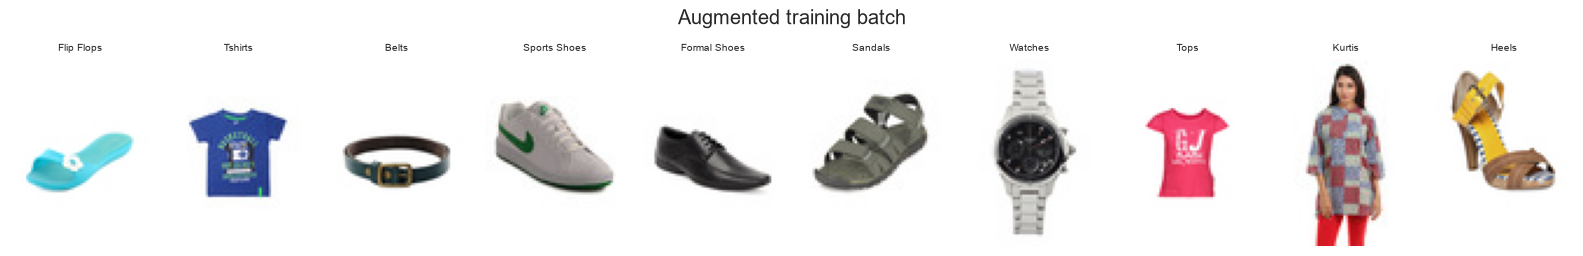

In [14]:
# ============================================
# CELL 14 - Inspect an augmented batch
# ============================================

denormalised = (
    images_batch[:10].permute(0, 2, 3, 1).numpy() * CHANNEL_STD + CHANNEL_MEAN
)

fig, axes = plt.subplots(1, 10, figsize=(16, 2.6))
for ax, image, lbl in zip(axes, denormalised, labels_batch[:10]):
    ax.imshow(np.clip(image, 0, 1))
    ax.set_title(class_names[lbl], fontsize=7)
    ax.axis("off")
plt.suptitle("Augmented training batch")
plt.tight_layout()
plt.show()

## 9. Class imbalance

Even after dropping rare classes, `Tshirts` (6,781) is roughly 680x larger than the smallest
surviving class (10). Inverse-frequency class weights are computed on the training split only
and capped to stop a tiny class from dominating the gradient.

In [15]:
# ============================================
# CELL 15 - Class weights
# ============================================

from sklearn.utils.class_weight import compute_class_weight

WEIGHT_CAP = 10.0
y_train = train_df["label"].to_numpy()
present = np.unique(y_train)

weights = np.ones(NUM_CLASSES, dtype=np.float32)
computed = compute_class_weight("balanced", classes=present, y=y_train)
weights[present] = computed
weights = np.clip(weights, 0.0, WEIGHT_CAP)

CLASS_WEIGHTS = torch.tensor(weights, dtype=torch.float32, device=DEVICE)

imbalance_ratio = train_df["label"].value_counts().max() / train_df["label"].value_counts().min()
print(f"Train-split class-count ratio (largest/smallest): {imbalance_ratio:.0f}:1")
print(f"Weights clipped to [0, {WEIGHT_CAP}]")

weight_table = pd.DataFrame({
    "Class": class_names,
    "TrainCount": [int((y_train == i).sum()) for i in range(NUM_CLASSES)],
    "Weight": weights.round(3),
}).sort_values("TrainCount")
display(weight_table.head(10))
display(weight_table.tail(10))

Train-split class-count ratio (largest/smallest): 606:1
Weights clipped to [0, 10.0]


,Class,TrainCount,Weight
59,Rucksacks,8,10.0
3,Basketballs,9,10.0
25,Foundation and Primer,9,10.0
5,Booties,9,10.0
36,Jumpsuit,9,10.0
43,Lip Liner,9,10.0
37,Kajal and Eyeliner,9,10.0
58,Rompers,9,10.0
91,Water Bottle,9,10.0
82,Travel Accessory,10,10.0


,Class,TrainCount,Weight
73,Sunglasses,749,0.399
30,Heels,749,0.399
29,Handbags,1028,0.291
39,Kurtas,1112,0.269
79,Tops,1154,0.259
70,Sports Shoes,1423,0.210
90,Watches,1609,0.186
13,Casual Shoes,1917,0.156
64,Shirts,2205,0.136
85,Tshirts,4844,0.062


## 10. Model architectures

Three algorithm families, as set out in the introduction:

* **Classical.** Hand-crafted HSV colour histogram (48 features) + a coarse gradient-magnitude
  texture grid (32 features) -> `StandardScaler` -> `LogisticRegression`. No learned visual
  features, no gradient descent over pixels.
* **MLP.** Fully connected network on flattened pixels — discards spatial structure entirely,
  included to demonstrate why convolution is the right inductive bias (same logic as Task 3's
  `MultiTaskMLP` control).
* **CNN.** Four `ConvBlock`s (Conv-BN-ReLU x2 + max-pool), global average pooling, one
  classification head — the submitted model. Reuses Task 3's exact `ConvBlock`; only the head
  width changed (92-way output needs more capacity than Task 3's 5/4-way heads). Depth is
  unchanged: at 60x80 input, four halving stages is already close to the useful limit
  (80x60 -> 40x30 -> 20x15 -> 10x7 -> 5x3).

In [16]:
# ============================================
# CELL 16 - Classical hand-crafted features
# ============================================

def extract_hsv_histogram(rgb_array, bins=16):
    """16-bin histogram per HSV channel -> 48 features. Pure numpy/PIL, no new dependency."""
    img = Image.fromarray(rgb_array, mode="RGB").convert("HSV")
    hsv = np.asarray(img, dtype=np.uint8)
    feats = []
    for channel in range(3):
        hist, _ = np.histogram(hsv[:, :, channel], bins=bins, range=(0, 255))
        feats.append(hist / hist.sum())
    return np.concatenate(feats)


def extract_gradient_grid(rgb_array, grid=4):
    """Mean+std gradient magnitude per cell of a grid x grid split -> 2*grid*grid features."""
    gray = np.asarray(Image.fromarray(rgb_array, mode="RGB").convert("L"), dtype=np.float32)
    gy, gx = np.gradient(gray)
    magnitude = np.sqrt(gx ** 2 + gy ** 2)
    h, w = magnitude.shape
    h_edges = np.linspace(0, h, grid + 1).astype(int)
    w_edges = np.linspace(0, w, grid + 1).astype(int)
    feats = []
    for i in range(grid):
        for j in range(grid):
            cell = magnitude[h_edges[i]:h_edges[i + 1], w_edges[j]:w_edges[j + 1]]
            feats.append(cell.mean())
            feats.append(cell.std())
    return np.asarray(feats, dtype=np.float32)


def extract_classical_features(rgb_array):
    return np.concatenate([extract_hsv_histogram(rgb_array), extract_gradient_grid(rgb_array)])


def build_classical_matrix(frame):
    positions = frame["cache_position"].to_numpy()
    feats = np.stack([extract_classical_features(np.asarray(IMAGES[p])) for p in positions])
    return feats.astype(np.float32)


print("Classical feature dimensionality:",
      len(extract_classical_features(np.asarray(IMAGES[0]))))

Classical feature dimensionality: 80


In [17]:
# ============================================
# CELL 17 - CNN and MLP architectures
# ============================================

class ConvBlock(nn.Module):
    """Conv-BN-ReLU x2 followed by max-pooling."""

    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

    def forward(self, x):
        return self.block(x)


class ItemTypeCNN(nn.Module):
    def __init__(self, num_classes, widths=(16, 32, 64, 128), dropout=0.4, head_hidden=128):
        super().__init__()
        channels = 3
        blocks = []
        for width in widths:
            blocks.append(ConvBlock(channels, width))
            channels = width
        self.backbone = nn.Sequential(*blocks)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(channels, head_hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(head_hidden, num_classes),
        )

    def forward(self, x):
        features = self.pool(self.backbone(x)).flatten(1)
        return self.head(features)


class ItemTypeMLP(nn.Module):
    """Fully connected baseline - discards spatial structure entirely."""

    def __init__(self, num_classes, hidden=(256, 128), dropout=0.4):
        super().__init__()
        in_features = IMAGE_SHAPE[0] * IMAGE_SHAPE[1] * IMAGE_SHAPE[2]
        layers, previous = [], in_features
        for size in hidden:
            layers += [nn.Linear(previous, size), nn.BatchNorm1d(size),
                       nn.ReLU(inplace=True), nn.Dropout(dropout)]
            previous = size
        self.body = nn.Sequential(*layers)
        self.head = nn.Linear(previous, num_classes)

    def forward(self, x):
        return self.head(self.body(x.flatten(1)))


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


for name, model in [
    ("ItemTypeCNN", ItemTypeCNN(NUM_CLASSES, widths=CONFIG["widths"],
                                 dropout=CONFIG["dropout"], head_hidden=CONFIG["head_hidden"])),
    ("ItemTypeMLP", ItemTypeMLP(NUM_CLASSES)),
]:
    print(f"{name:14s} {count_parameters(model):>10,} trainable parameters")

ItemTypeCNN       322,380 trainable parameters
ItemTypeMLP     3,732,188 trainable parameters


## 11. Training and evaluation machinery

**Model selection metric: validation weighted-F1** (not macro-F1, unlike Task 3). With several
classes near the 10-sample floor, macro-F1 on a small validation slice is too noisy to guide
early stopping reliably; weighted-F1 tracks performance on the population that actually exists.
Macro-F1 and balanced accuracy are still computed and reported for the long-tail diagnostic.
Top-3 / top-5 accuracy are added because with 92 fine-grained, visually overlapping classes
(`Casual Shoes` vs `Sports Shoes` vs `Formal Shoes`; `Tops` vs `Tshirts` vs `Shirts`), whether
the correct label is in the model's top few guesses is a standard and informative measure.

In [18]:
# ============================================
# CELL 18 - AMP helpers (version tolerant)
# ============================================

USE_AMP = bool(CONFIG["use_amp"]) and DEVICE.type == "cuda"

try:
    from torch.amp import GradScaler as _GradScaler, autocast as _autocast

    def make_scaler():
        return _GradScaler("cuda", enabled=USE_AMP)

    def amp_autocast():
        return _autocast("cuda", enabled=USE_AMP)

except (ImportError, TypeError):
    from torch.cuda.amp import GradScaler as _GradScaler, autocast as _autocast

    def make_scaler():
        return _GradScaler(enabled=USE_AMP)

    def amp_autocast():
        return _autocast(enabled=USE_AMP)

print("Mixed precision enabled:", USE_AMP, f"(device={DEVICE.type})")

Mixed precision enabled: False (device=cpu)


In [19]:
# ============================================
# CELL 19 - Metrics
# ============================================

def top_k_accuracy(y_true, y_prob, k):
    top_k = np.argsort(-y_prob, axis=1)[:, :k]
    return float((top_k == y_true[:, None]).any(axis=1).mean())


def compute_metrics(y_true, y_pred, y_prob=None):
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred) * 100,
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0) * 100,
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0) * 100,
        "balanced_acc": balanced_accuracy_score(y_true, y_pred) * 100,
    }
    if y_prob is not None:
        metrics["top3_acc"] = top_k_accuracy(y_true, y_prob, 3) * 100
        metrics["top5_acc"] = top_k_accuracy(y_true, y_prob, 5) * 100
    return metrics


def metrics_row(metrics, label=""):
    row = {"Model": label}
    row.update({k: round(v, 2) for k, v in metrics.items()})
    return row

In [20]:
# ============================================
# CELL 20 - Prediction and training loops
# ============================================

@torch.no_grad()
def predict(model, loader):
    """Return (y_true, y_pred, y_prob) for a neural model."""
    model.eval()
    trues, preds, probs = [], [], []
    for images, labels in loader:
        images = images.to(DEVICE, non_blocking=True)
        with amp_autocast():
            logits = model(images).float()
        trues.append(labels.numpy())
        preds.append(logits.argmax(1).cpu().numpy())
        probs.append(F.softmax(logits, dim=1).cpu().numpy())
    return np.concatenate(trues), np.concatenate(preds), np.concatenate(probs)


def train_model(model, loader_train, loader_val, config=None, tag="model", verbose=True):
    """Train with early stopping on validation weighted-F1. Returns (model, history)."""
    cfg = {**CONFIG, **(config or {})}
    model = model.to(DEVICE)

    criterion = nn.CrossEntropyLoss(
        weight=CLASS_WEIGHTS if cfg["use_class_weights"] else None,
        label_smoothing=cfg.get("label_smoothing", 0.0),
    )

    optimizer = torch.optim.AdamW(
        model.parameters(), lr=cfg["learning_rate"], weight_decay=cfg["weight_decay"]
    )
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=cfg["lr_patience"]
    )
    scaler = make_scaler()

    history = []
    best_score, best_state, best_epoch, stale = -np.inf, None, -1, 0
    start = time.time()

    for epoch in range(cfg["max_epochs"]):
        model.train()
        running_loss, running_n = 0.0, 0

        for images, labels in loader_train:
            images = images.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with amp_autocast():
                logits = model(images)
                loss = criterion(logits, labels)

            scaler.scale(loss).backward()
            if cfg["grad_clip"]:
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), cfg["grad_clip"])
            scaler.step(optimizer)
            scaler.update()

            batch = images.size(0)
            running_loss += loss.item() * batch
            running_n += batch

        y_true, y_pred, y_prob = predict(model, loader_val)
        val_metrics = compute_metrics(y_true, y_pred, y_prob)
        score = val_metrics["weighted_f1"]
        scheduler.step(score)

        record = {
            "epoch": epoch + 1,
            "train_loss": running_loss / running_n,
            "val_weighted_f1": score,
            "val_macro_f1": val_metrics["macro_f1"],
            "val_accuracy": val_metrics["accuracy"],
            "val_top3_acc": val_metrics["top3_acc"],
            "lr": optimizer.param_groups[0]["lr"],
        }
        history.append(record)

        if score > best_score + 1e-4:
            best_score, best_epoch, stale = score, epoch + 1, 0
            best_state = copy.deepcopy(model.state_dict())
        else:
            stale += 1

        if verbose:
            print(f"[{tag}] epoch {epoch + 1:>3}/{cfg['max_epochs']} "
                  f"loss {record['train_loss']:.4f} | "
                  f"val weighted-F1 {score:.2f} macro-F1 {val_metrics['macro_f1']:.2f} "
                  f"top3 {val_metrics['top3_acc']:.2f}"
                  f"{'  <- best' if stale == 0 else ''}")

        if stale >= cfg["early_stopping_patience"]:
            if verbose:
                print(f"[{tag}] early stopping at epoch {epoch + 1} "
                      f"(no improvement for {stale} epochs)")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    elapsed = time.time() - start
    if verbose:
        print(f"[{tag}] done in {elapsed / 60:.1f} min | "
              f"best val weighted-F1 {best_score:.2f} at epoch {best_epoch}")

    return model, pd.DataFrame(history)

In [21]:
# ============================================
# CELL 21 - Training curve plot
# ============================================

def plot_history(history, title=""):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history["epoch"], history["train_loss"])
    axes[0].set_xlabel("epoch"); axes[0].set_ylabel("training loss")
    axes[0].set_title("Training loss")

    axes[1].plot(history["epoch"], history["val_weighted_f1"], label="weighted-F1")
    axes[1].plot(history["epoch"], history["val_macro_f1"], label="macro-F1")
    axes[1].plot(history["epoch"], history["val_top3_acc"], label="top-3 acc")
    best = history.loc[history["val_weighted_f1"].idxmax()]
    axes[1].axvline(best["epoch"], color="r", ls="--",
                     label=f"best (epoch {int(best['epoch'])})")
    axes[1].set_xlabel("epoch"); axes[1].set_ylabel("validation metric (%)")
    axes[1].set_title("Validation metrics"); axes[1].legend()

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

In [22]:
# ============================================
# CELL 22 - Result stores and the experiment runner
# ============================================

RESULTS = {}
HISTORIES = {}
MODELS = {}


def run_experiment(name, model_factory, config=None, augmentation=None, class_weights=None):
    """Train one CNN/MLP configuration and record its validation performance."""
    set_seed()
    loader_train = make_loader(train_df, train=True, augmentation=augmentation)

    merged = {"max_epochs": CONFIG["ablation_max_epochs"],
              "early_stopping_patience": CONFIG["ablation_patience"]}
    if class_weights is not None:
        merged["use_class_weights"] = class_weights
    merged.update(config or {})

    model, history = train_model(model_factory(), loader_train, val_loader,
                                  config=merged, tag=name)
    y_true, y_pred, y_prob = predict(model, val_loader)
    metrics = compute_metrics(y_true, y_pred, y_prob)

    RESULTS[name] = metrics
    HISTORIES[name] = history
    MODELS[name] = model

    print(f"\n--- {name} (validation) ---")
    display(pd.DataFrame([metrics_row(metrics, name)]))
    return model, history

## 12. Train all models on the fixed split

In [ ]:
# ============================================
# CELL 23 - Classical pipeline (HSV histogram + gradient grid -> LogisticRegression)
# ============================================

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

start = time.time()
X_train_classical = build_classical_matrix(train_df)
X_val_classical = build_classical_matrix(val_df)
print(f"Feature extraction: {time.time() - start:.1f}s "
      f"for {len(train_df) + len(val_df)} images")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_classical)
X_val_scaled = scaler.transform(X_val_classical)

start = time.time()
classical_model = LogisticRegression(max_iter=2000, C=1.0,
                                      class_weight="balanced", n_jobs=-1)
classical_model.fit(X_train_scaled, train_df["label"].to_numpy())
print(f"LogisticRegression training: {time.time() - start:.1f}s")

y_val_true = val_df["label"].to_numpy()
y_val_pred = classical_model.predict(X_val_scaled)
y_val_prob = classical_model.predict_proba(X_val_scaled)
# predict_proba columns follow classical_model.classes_, which may be a subset of
# range(NUM_CLASSES) if a class never appears in the training split - realign to
# the full label space so top-k accuracy indexes correctly.
full_prob = np.zeros((len(y_val_pred), NUM_CLASSES), dtype=np.float32)
full_prob[:, classical_model.classes_] = y_val_prob

classical_metrics = compute_metrics(y_val_true, y_val_pred, full_prob)
RESULTS["Classical_LogReg"] = classical_metrics
display(pd.DataFrame([metrics_row(classical_metrics, "Classical_LogReg")]))

In [ ]:
# ============================================
# CELL 24 - MLP baseline
# ============================================

run_experiment("MLP", lambda: ItemTypeMLP(NUM_CLASSES))

In [ ]:
# ============================================
# CELL 25 - CNN (starting configuration)
# ============================================

run_experiment(
    "CNN_start",
    lambda: ItemTypeCNN(NUM_CLASSES, widths=CONFIG["widths"],
                         dropout=CONFIG["dropout"], head_hidden=CONFIG["head_hidden"]),
)
plot_history(HISTORIES["CNN_start"], "CNN_start")

In [ ]:
# ============================================
# CELL 26 - Comparison table (validation)
# ============================================

comparison_rows = []
comparison_rows.append({
    "Model": "Baseline_majority",
    "accuracy": BASELINE["Accuracy"], "macro_f1": BASELINE["MacroF1"],
    "weighted_f1": BASELINE["WeightedF1"], "balanced_acc": BASELINE["BalancedAcc"],
    "top3_acc": np.nan, "top5_acc": np.nan,
})
for name in ["Classical_LogReg", "MLP", "CNN_start"]:
    comparison_rows.append(metrics_row(RESULTS[name], name))

baseline_and_model_comparison = pd.DataFrame(comparison_rows).round(2)
display(baseline_and_model_comparison)
baseline_and_model_comparison.to_csv(ARTIFACT_DIR / "baseline_and_model_comparison.csv", index=False)
print("Saved", ARTIFACT_DIR / "baseline_and_model_comparison.csv")

## 13. Hyper-parameter search and ablations

A small random search around the starting configuration (`CONFIG["search_budget"]` trials,
capped at `CONFIG["ablation_max_epochs"]` epochs each), followed by single-factor ablations for
augmentation strength and class weighting. All comparisons select on validation weighted-F1.

In [ ]:
# ============================================
# CELL 27 - Random hyper-parameter search
# ============================================

SEARCH_SPACE = {
    "learning_rate": [5e-4, 1e-3],
    "dropout": [0.3, 0.4, 0.5],
    "head_hidden": [128, 256],
    "widths": [(16, 32, 64, 128), (24, 48, 96, 192)],
}

rng = np.random.default_rng(RANDOM_STATE)
search_rows = []
best_trial = None
seen = set()

for trial in range(CONFIG["search_budget"]):
    for _ in range(50):
        sampled = {k: v[rng.integers(len(v))] for k, v in SEARCH_SPACE.items()}
        key = tuple(str(sampled[k]) for k in sorted(sampled))
        if key not in seen:
            seen.add(key)
            break

    print(f"\n=== trial {trial + 1}/{CONFIG['search_budget']} === {sampled}")

    set_seed(RANDOM_STATE + trial)
    model_factory = lambda s=sampled: ItemTypeCNN(
        NUM_CLASSES, widths=tuple(s["widths"]), dropout=float(s["dropout"]),
        head_hidden=int(s["head_hidden"]),
    )
    trial_config = {"learning_rate": float(sampled["learning_rate"])}

    loader_train = make_loader(train_df, train=True)
    model, history = train_model(model_factory(), loader_train, val_loader,
                                  config={**trial_config,
                                          "max_epochs": CONFIG["ablation_max_epochs"],
                                          "early_stopping_patience": CONFIG["ablation_patience"]},
                                  tag=f"trial{trial + 1}", verbose=False)
    y_true, y_pred, y_prob = predict(model, val_loader)
    metrics = compute_metrics(y_true, y_pred, y_prob)

    row = {**{k: str(v) for k, v in sampled.items()},
           "WeightedF1": round(metrics["weighted_f1"], 2),
           "MacroF1": round(metrics["macro_f1"], 2),
           "Top3Acc": round(metrics["top3_acc"], 2),
           "Epochs": len(history)}
    search_rows.append(row)
    print(f"    weighted-F1 = {row['WeightedF1']}  top3 = {row['Top3Acc']}")

    if best_trial is None or row["WeightedF1"] > best_trial["row"]["WeightedF1"]:
        best_trial = {"row": row, "sampled": sampled, "config": trial_config,
                      "model": model, "history": history}

search_df = pd.DataFrame(search_rows).sort_values("WeightedF1", ascending=False)
display(search_df)
print("\nBest sampled configuration:", best_trial["sampled"])

In [ ]:
# ============================================
# CELL 28 - Augmentation and class-weight ablations
# ============================================

BEST = best_trial["sampled"]
BEST_CONFIG = best_trial["config"]


def build_best_model():
    return ItemTypeCNN(NUM_CLASSES, widths=tuple(BEST["widths"]),
                        dropout=float(BEST["dropout"]), head_hidden=int(BEST["head_hidden"]))


MODELS["CNN_tuned"] = best_trial["model"]
HISTORIES["CNN_tuned"] = best_trial["history"]
_y_true, _y_pred, _y_prob = predict(best_trial["model"], val_loader)
RESULTS["CNN_tuned"] = compute_metrics(_y_true, _y_pred, _y_prob)

run_experiment("CNN_aug_none", build_best_model, config=BEST_CONFIG, augmentation="none")
run_experiment("CNN_aug_heavy", build_best_model, config=BEST_CONFIG, augmentation="heavy")
run_experiment("CNN_no_class_weights", build_best_model, config=BEST_CONFIG, class_weights=False)

ablation_summary = pd.DataFrame([
    metrics_row(RESULTS[name], name)
    for name in ["CNN_tuned", "CNN_aug_none", "CNN_aug_heavy", "CNN_no_class_weights"]
]).round(2)
display(ablation_summary)
ablation_summary.to_csv(ARTIFACT_DIR / "hyperparameter_search.csv", index=False)
search_df.to_csv(ARTIFACT_DIR / "hyperparameter_search_trials.csv", index=False)
print("Saved", ARTIFACT_DIR / "hyperparameter_search.csv",
      "and", ARTIFACT_DIR / "hyperparameter_search_trials.csv")

## 14. Seed-robustness check (cross-validation substitute)

With the rarest surviving class holding only 10 examples, a k-fold split would leave too few
examples per class per fold to be meaningful (see notebook introduction). Instead, the winning
configuration is retrained from 3 different random seeds on the *same* split, giving a
noise-floor standard deviation for the headline metrics.

In [ ]:
# ============================================
# CELL 29 - Seed-robustness runs
# ============================================

seed_rows = []
for seed in range(CONFIG["seed_repeats"]):
    set_seed(RANDOM_STATE + 100 + seed)
    loader_train = make_loader(train_df, train=True)
    model, history = train_model(build_best_model(), loader_train, val_loader,
                                  config={**BEST_CONFIG,
                                          "max_epochs": CONFIG["ablation_max_epochs"],
                                          "early_stopping_patience": CONFIG["ablation_patience"]},
                                  tag=f"seed{seed}", verbose=False)
    y_true, y_pred, y_prob = predict(model, val_loader)
    metrics = compute_metrics(y_true, y_pred, y_prob)
    seed_rows.append({"Seed": RANDOM_STATE + 100 + seed, **{k: round(v, 2) for k, v in metrics.items()}})
    print(f"seed {seed}: weighted-F1 {metrics['weighted_f1']:.2f}  top3 {metrics['top3_acc']:.2f}")

seed_df = pd.DataFrame(seed_rows)
display(seed_df)

SEED_STD = float(seed_df["weighted_f1"].std())
SEED_MEAN = float(seed_df["weighted_f1"].mean())
print(f"\nNOISE FLOOR: weighted-F1 = {SEED_MEAN:.2f} +- {SEED_STD:.2f} "
      f"across {CONFIG['seed_repeats']} seeds.")
print("Differences between configurations smaller than this are not meaningful.")

seed_df.to_csv(ARTIFACT_DIR / "seed_robustness.csv", index=False)
print("Saved", ARTIFACT_DIR / "seed_robustness.csv")

## 15. Final model selection

Among the CNN configurations trained above, the winning search trial (`CNN_tuned`) is adopted
as `FINAL_MODEL` provided it is not worse than the simpler starting configuration by more than
the seed-robustness noise floor. Otherwise the simpler/cheaper configuration is preferred, on
the same "prefer the smallest model within the noise floor" principle Task 3 used.

In [ ]:
# ============================================
# CELL 30 - Adopt the final CNN configuration
# ============================================

candidates = {
    "CNN_start": (RESULTS["CNN_start"]["weighted_f1"], count_parameters(MODELS["CNN_start"])),
    "CNN_tuned": (RESULTS["CNN_tuned"]["weighted_f1"], count_parameters(MODELS["CNN_tuned"])),
}
for name, (score, params) in candidates.items():
    print(f"{name:12s} weighted-F1 {score:.2f}  params {params:,}")

best_score = max(score for score, _ in candidates.values())
within_noise_floor = [n for n, (score, _) in candidates.items()
                       if best_score - score <= SEED_STD]
FINAL_NAME = min(within_noise_floor, key=lambda n: candidates[n][1])
FINAL_MODEL = MODELS[FINAL_NAME]

print(f"\nAdopted final model: {FINAL_NAME} "
      f"(within {SEED_STD:.2f} weighted-F1 of the best, fewest parameters "
      f"among ties: {count_parameters(FINAL_MODEL):,})")

with open(ARTIFACT_DIR / "best_config.json", "w") as f:
    json.dump({"final_model": FINAL_NAME,
               "sampled": {k: str(v) for k, v in BEST.items()},
               "train_config": BEST_CONFIG,
               "seed_mean_weighted_f1": SEED_MEAN,
               "seed_std_weighted_f1": SEED_STD}, f, indent=2)
print("Saved", ARTIFACT_DIR / "best_config.json")

## 16. Held-out test evaluation

The test split has not been touched by any model-selection or hyper-parameter decision above.

In [ ]:
# ============================================
# CELL 31 - Test-set metrics
# ============================================

y_test_true, y_test_pred, y_test_prob = predict(FINAL_MODEL, test_loader)
test_metrics = compute_metrics(y_test_true, y_test_pred, y_test_prob)

final_comparison = baseline_and_model_comparison.copy()
final_comparison = pd.concat([
    final_comparison,
    pd.DataFrame([metrics_row(test_metrics, f"{FINAL_NAME}_TEST")]),
], ignore_index=True).round(2)
display(final_comparison)

final_comparison.to_csv(ARTIFACT_DIR / "final_test_metrics.csv", index=False)
final_comparison.to_csv(OUTPUT_EVAL_DIR / "item_type_results.csv", index=False)
print("Saved", ARTIFACT_DIR / "final_test_metrics.csv")
print("Saved", OUTPUT_EVAL_DIR / "item_type_results.csv")

gain = test_metrics["weighted_f1"] - BASELINE["WeightedF1"]
print(f"\nFinal model test weighted-F1: {test_metrics['weighted_f1']:.2f}% "
      f"(+{gain:.2f} points over the majority baseline)")
if gain <= 15:
    print("WARNING: gain over baseline is smaller than expected for a 92-class CNN - "
          "double check for a pipeline bug (label misalignment, cache desync, etc.)")

In [ ]:
# ============================================
# CELL 32 - Full classification report (saved, not fully printed - 92 classes)
# ============================================

report_text = classification_report(
    y_test_true, y_test_pred, target_names=class_names, zero_division=0
)
with open(ARTIFACT_DIR / "classification_report.txt", "w") as f:
    f.write(report_text)
print("Saved", ARTIFACT_DIR / "classification_report.txt")
print(report_text[:1500], "\n... (truncated - see saved file for all 92 classes)")

In [ ]:
# ============================================
# CELL 33 - Confusion matrix (top-25 most frequent classes)
# ============================================

top25 = train_df["label"].value_counts().head(25).index.tolist()
top25_names = [class_names[i] for i in top25]

mask = np.isin(y_test_true, top25)
y_true_sub = y_test_true[mask]
y_pred_sub = np.where(np.isin(y_test_pred[mask], top25), y_test_pred[mask], -1)

label_order = top25 + [-1]
cm = confusion_matrix(y_true_sub, y_pred_sub, labels=label_order, normalize="true")
tick_labels = top25_names + ["(other)"]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cm, xticklabels=tick_labels, yticklabels=top25_names, cmap="viridis",
            ax=ax, cbar_kws={"label": "row-normalised proportion"})
ax.set_xlabel("predicted"); ax.set_ylabel("true")
ax.set_title("Confusion matrix - 25 most frequent classes (test set)")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# CELL 34 - Most confused class pairs (whole test set)
# ============================================

pred_df = pd.DataFrame({
    "true": [class_names[i] for i in y_test_true],
    "pred": [class_names[i] for i in y_test_pred],
})
confused = pred_df[pred_df["true"] != pred_df["pred"]]
most_confused = (confused.groupby(["true", "pred"]).size()
                  .sort_values(ascending=False).head(15).to_frame("count"))
display(most_confused)

In [ ]:
# ============================================
# CELL 35 - Error analysis: most confident misclassifications
# ============================================

confidences = y_test_prob[np.arange(len(y_test_prob)), y_test_pred]
errors_mask = y_test_true != y_test_pred
error_idx = np.where(errors_mask)[0]
error_idx = error_idx[np.argsort(-confidences[error_idx])][:9]

test_positions = test_df["cache_position"].to_numpy()
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for ax, idx in zip(axes.ravel(), error_idx):
    image = np.asarray(IMAGES[test_positions[idx]])
    ax.imshow(image)
    ax.set_title(f"true: {class_names[y_test_true[idx]]}\n"
                 f"pred: {class_names[y_test_pred[idx]]} ({confidences[idx]:.2f})",
                 fontsize=8)
    ax.axis("off")
plt.suptitle("Most confident misclassifications (test set)")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================
# CELL 36 - Confidence / coverage operating-threshold table
# ============================================

threshold_rows = []
correct = (y_test_pred == y_test_true)
for threshold in [0.0, 0.3, 0.5, 0.7, 0.9]:
    confident = confidences >= threshold
    if confident.sum() < 20:
        continue
    threshold_rows.append({
        "Threshold": threshold,
        "Coverage%": round(confident.mean() * 100, 1),
        "Accuracy%": round(correct[confident].mean() * 100, 2),
        "n": int(confident.sum()),
    })

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df)

monotonic = threshold_df["Accuracy%"].is_monotonic_increasing
print(f"Calibration sanity check (accuracy should rise with the threshold): "
      f"{'PASS' if monotonic else 'FAIL - probabilities may be miscalibrated'}")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(threshold_df["Coverage%"], threshold_df["Accuracy%"], "o-")
ax.set_xlabel("coverage - % of items auto-tagged")
ax.set_ylabel("accuracy on the auto-tagged items (%)")
ax.set_title("Coverage vs accuracy - the deployment trade-off")
plt.tight_layout()
plt.show()

## 17. Data-quality analysis

Required analysis: how does the rare-class drop affect results, and is the chosen threshold
justified by evidence rather than convenience?

In [ ]:
# ============================================
# CELL 37 - Quantify the dropped-class impact
# ============================================

with open(ARTIFACT_DIR / "dropped_classes.json") as f:
    dropped = json.load(f)

dropped_rows_total = sum(d["count"] for d in dropped)
estimated_unseen_affected = len(prediction_df_raw) * dropped_rows_total / n_start

print(f"Classes dropped: {len(dropped)}")
print(f"Training rows dropped: {dropped_rows_total} ({dropped_rows_total / n_start * 100:.2f}%)")
print(f"Estimated unseen rows whose true class was dropped "
      f"(proportional to training incidence): {estimated_unseen_affected:.0f} "
      f"({estimated_unseen_affected / len(prediction_df_raw) * 100:.2f}%)")
print("\nThese items can never be predicted correctly by this model, because their true")
print("class has no output logit. This is the direct, quantified cost of the min_class_size")
print("threshold, and is reported here rather than left implicit.")

display(pd.DataFrame(dropped).sort_values("count", ascending=False))

In [ ]:
# ============================================
# CELL 38 - Was the threshold choice reasonable? A lighter-weight check
# ============================================

# Re-running the full CNN pipeline at another threshold would cost another
# full training run; the classical pipeline (already fast: seconds, not
# minutes) is used instead purely to check the DIRECTION of the effect, not
# to pick a different final model.

alt_min_size = 5
alt_rare = counts[counts < alt_min_size].index.tolist()
alt_df = data[~data[target].isin(alt_rare)].copy()
alt_df["label"] = LabelEncoder().fit_transform(alt_df[target].astype(str))
alt_df["split_group"] = alt_df[CONFIG["group_column"]].fillna("__ID_" + alt_df["id"].astype(str))

alt_trainval, alt_test = grouped_split(alt_df, alt_df["label"], alt_df["split_group"],
                                        CONFIG["test_fraction"], RANDOM_STATE)
alt_train, alt_val = grouped_split(alt_trainval, alt_trainval["label"],
                                    alt_trainval["split_group"], val_fraction_adj, RANDOM_STATE)

alt_id_to_pos = {}
alt_ids_needed = pd.concat([alt_train, alt_val])["id"].to_numpy()
missing_from_cache = set(alt_ids_needed) - set(all_ids)
print(f"IDs in the {alt_min_size}-threshold split not covered by the existing "
      f"{CONFIG['min_class_size']}-threshold cache: {len(missing_from_cache)}")

# Only rows already present in the min_class_size=10 cache can be scored without
# rebuilding the image cache; this is a large majority of alt_train/alt_val since
# the two taxonomies overlap heavily, and is sufficient to show the direction of
# the effect (the goal of this section).
alt_train_covered = alt_train[alt_train["id"].isin(id_to_position)].copy()
alt_val_covered = alt_val[alt_val["id"].isin(id_to_position)].copy()
alt_train_covered["cache_position"] = alt_train_covered["id"].map(id_to_position)
alt_val_covered["cache_position"] = alt_val_covered["id"].map(id_to_position)

X_alt_train = build_classical_matrix(alt_train_covered)
X_alt_val = build_classical_matrix(alt_val_covered)
alt_scaler = StandardScaler()
alt_model = LogisticRegression(max_iter=2000, C=1.0,
                                class_weight="balanced", n_jobs=-1)
alt_model.fit(alt_scaler.fit_transform(X_alt_train), alt_train_covered["label"].to_numpy())

alt_pred = alt_model.predict(alt_scaler.transform(X_alt_val))
alt_true = alt_val_covered["label"].to_numpy()
alt_metrics = compute_metrics(alt_true, alt_pred)

threshold_comparison = pd.DataFrame([
    {"min_class_size": CONFIG["min_class_size"], "classes": NUM_CLASSES,
     "weighted_f1": classical_metrics["weighted_f1"], "macro_f1": classical_metrics["macro_f1"]},
    {"min_class_size": alt_min_size, "classes": alt_df["label"].nunique(),
     "weighted_f1": alt_metrics["weighted_f1"], "macro_f1": alt_metrics["macro_f1"]},
]).round(2)
display(threshold_comparison)
print("\nBoth rows use the same classical (HSV+gradient / LogisticRegression) pipeline,")
print("so the comparison isolates the effect of the threshold, not the choice of model.")
threshold_comparison.to_csv(ARTIFACT_DIR / "threshold_ablation.csv", index=False)

## 18. Save artefacts

In [ ]:
# ============================================
# CELL 39 - Persist the final model and metadata
# ============================================

MODEL_PATH = ARTIFACT_DIR / "task1_cnn.pt"

final_architecture = {
    "widths": list(BEST["widths"]) if FINAL_NAME == "CNN_tuned" else list(CONFIG["widths"]),
    "dropout": float(BEST["dropout"]) if FINAL_NAME == "CNN_tuned" else CONFIG["dropout"],
    "head_hidden": int(BEST["head_hidden"]) if FINAL_NAME == "CNN_tuned" else CONFIG["head_hidden"],
}

torch.save({
    "state_dict": FINAL_MODEL.state_dict(),
    "model_name": FINAL_NAME,
    "num_classes": NUM_CLASSES,
    "class_names": class_names,
    "channel_mean": CHANNEL_MEAN.tolist(),
    "channel_std": CHANNEL_STD.tolist(),
    "image_size_pil": list(IMAGE_SIZE_PIL),
    "architecture": final_architecture,
    "config": {k: (list(v) if isinstance(v, tuple) else v) for k, v in CONFIG.items()},
    "test_metrics": test_metrics,
}, MODEL_PATH)

print("Saved model ->", MODEL_PATH, f"({MODEL_PATH.stat().st_size / 1e6:.1f} MB)")

for path in sorted(ARTIFACT_DIR.iterdir()):
    print(" -", path.name)

## 19. Inference on the unlabelled test images

The same `load_image_array` and normalisation used in training are reused here, so training and
inference cannot diverge.

In [ ]:
# ============================================
# CELL 40 - Reusable inference function
# ============================================

def load_task1_model(path=MODEL_PATH, device=DEVICE):
    """Rebuild the trained model from disk - used by the notebook and the app backend."""
    checkpoint = torch.load(path, map_location=device)
    model = ItemTypeCNN(
        checkpoint["num_classes"],
        widths=tuple(checkpoint["architecture"]["widths"]),
        dropout=checkpoint["architecture"]["dropout"],
        head_hidden=checkpoint["architecture"]["head_hidden"],
    )
    model.load_state_dict(checkpoint["state_dict"])
    model.to(device).eval()
    return model, checkpoint


@torch.no_grad()
def predict_images(model, checkpoint, paths, batch_size=256, device=DEVICE):
    """Predict articleType for a list of image paths."""
    mean = np.array(checkpoint["channel_mean"], dtype=np.float32)
    std = np.array(checkpoint["channel_std"], dtype=np.float32)
    size = tuple(checkpoint["image_size_pil"])
    names = checkpoint["class_names"]

    labels, confs = [], []
    for start in range(0, len(paths), batch_size):
        chunk = paths[start:start + batch_size]
        arrays = np.stack([load_image_array(p, size) for p in chunk]).astype(np.float32) / 255.0
        arrays = (arrays - mean) / std
        tensor = torch.from_numpy(arrays.transpose(0, 3, 1, 2)).float().to(device)

        with amp_autocast():
            logits = model(tensor)
        probabilities = F.softmax(logits.float(), dim=1).cpu().numpy()
        indices = probabilities.argmax(1)
        labels += [names[i] for i in indices]
        confs += probabilities.max(1).tolist()

    return labels, confs


final_model, final_checkpoint = load_task1_model()
print("Reloaded model:", final_checkpoint["model_name"])
print("Classes:", len(final_checkpoint["class_names"]))

In [ ]:
# ============================================
# CELL 41 - Predict the unlabelled test set
# ============================================

prediction_df = prediction_df_raw.copy()
print("Unseen rows:", len(prediction_df))

test_paths = prediction_df["image_path"].tolist()
start = time.time()
pred_labels, pred_confidences = predict_images(final_model, final_checkpoint, test_paths)
elapsed = time.time() - start

prediction_df["articleType"] = pred_labels
prediction_df["articleType_confidence"] = np.round(pred_confidences, 4)

print(f"Inference: {elapsed:.1f}s for {len(test_paths)} images "
      f"({len(test_paths) / elapsed:.0f} images/second)")

assert prediction_df["articleType"].notna().all()
assert len(prediction_df) == 5829
assert set(prediction_df["articleType"]).issubset(set(class_names))

display(prediction_df.head(10))

In [ ]:
# ============================================
# CELL 42 - Save the Task 1 predictions
# ============================================

TASK1_PREDICTIONS = ARTIFACT_DIR / "task1_predictions.csv"
prediction_df.to_csv(TASK1_PREDICTIONS, index=False)
print("Saved", TASK1_PREDICTIONS)

submission_df = prediction_df_raw.drop(columns=["image_path"]).copy()
submission_df["articleType"] = pred_labels
SUBMISSION_PATH = OUTPUT_DIR / "task1_item_type_predictions.csv"
submission_df.to_csv(SUBMISSION_PATH, index=False)
print("Saved", SUBMISSION_PATH)

predicted_share = prediction_df["articleType"].value_counts(normalize=True)
training_share = train_df[target].value_counts(normalize=True)
drift = (predicted_share.reindex(training_share.index.union(predicted_share.index), fill_value=0)
         - training_share.reindex(training_share.index.union(predicted_share.index), fill_value=0)
         ).abs().sum() / 2 * 100
print(f"Total variation distance from training distribution: {drift:.1f}%")
print("(a large value suggests the model has collapsed toward common classes)")

## 20. Summary for the report

In [ ]:
# ============================================
# CELL 43 - Consolidated results
# ============================================

report_summary = {
    "rows_after_target_cleaning": n_start,
    "rows_after_rare_class_drop": len(model_df),
    "classes_before_drop": int(data[target].nunique()),
    "classes_after_drop": NUM_CLASSES,
    "classes_dropped": len(dropped),
    "train_rows": len(train_df),
    "val_rows": len(val_df),
    "test_rows": len(test_df),
    "final_model": FINAL_NAME,
    "parameters": count_parameters(FINAL_MODEL),
    "test_accuracy": round(test_metrics["accuracy"], 2),
    "test_weighted_f1": round(test_metrics["weighted_f1"], 2),
    "test_macro_f1": round(test_metrics["macro_f1"], 2),
    "test_balanced_acc": round(test_metrics["balanced_acc"], 2),
    "test_top3_acc": round(test_metrics["top3_acc"], 2),
    "test_top5_acc": round(test_metrics["top5_acc"], 2),
    "baseline_accuracy": BASELINE["Accuracy"],
    "baseline_weighted_f1": BASELINE["WeightedF1"],
    "classical_weighted_f1": round(classical_metrics["weighted_f1"], 2),
    "mlp_weighted_f1": round(RESULTS["MLP"]["weighted_f1"], 2),
    "seed_mean_weighted_f1": round(SEED_MEAN, 2),
    "seed_std_weighted_f1": round(SEED_STD, 2),
    "estimated_unseen_rows_with_dropped_true_class": round(estimated_unseen_affected, 1),
}

display(pd.Series(report_summary).to_frame("Value"))

with open(ARTIFACT_DIR / "task1_summary.json", "w") as f:
    json.dump(report_summary, f, indent=2)
print("Saved", ARTIFACT_DIR / "task1_summary.json")

### Points to carry into the written report

* **Rare-class handling.** 32 of 124 `articleType` classes (0.31% of rows) were dropped rather
  than merged, because no defensible merge target exists for a set of unrelated micro-categories
  and Task 3 already demonstrated a catch-all class costs far more than it saves. The estimated
  cost — roughly `estimated_unseen_rows_with_dropped_true_class` unseen rows that can never be
  predicted correctly — is reported explicitly rather than hidden.
* **Different algorithm families.** Classical (HSV histogram + gradient grid ->
  LogisticRegression), MLP-on-pixels, and CNN were all trained and compared on identical splits.
* **Metric choice.** Weighted-F1 and top-3 accuracy are the headline numbers because macro-F1 is
  noise-dominated with several classes near the 10-sample floor; macro-F1/balanced-accuracy are
  retained as the long-tail diagnostic.
* **Compute budget.** This machine is CPU-only. Architecture width, epoch budget and search
  budget were all sized down from Task 3's GPU-era defaults; a GPU re-run should widen them.
* **Robustness.** A 3-seed repeat (not k-fold CV, which would leave too few examples per class
  per fold) gives the noise floor used throughout Sections 13-15.